# Analisi swap — LLaVA su VQAv2
Notebook rigenerato. Path derivati da un unico `CACHE` (nuova cartella, cache pulita).
Esegui dall'alto al basso a kernel riavviato.

In [1]:
# 0.1 — Config (unica sorgente dei path: CACHE)
import os, re, math, json, random, time
from contextlib import contextmanager
from datasets import load_dataset
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---- MODELLO ----
MODEL_NAME = "llava"
MODEL_ID   = "llava-hf/llava-1.5-7b-hf"
USE_4BIT   = False
DTYPE      = torch.bfloat16
DEVICE     = "cuda:0"

METHODS = ["J-taylor", "J-taylor-raw", "J", "JV-pinv", "logit",
           "project_away", "pai", "pai_targeted"]

# ---- lenti Jacobiane gia' calcolate ----
LENS_FILES        = ["lenses_JV_paper_JT_paper.pt", "lenses.pt"]
LENS_DIR_OVERRIDE = None
_LENS_CANDIDATES  = [
    "./Corretto/jlens_llm_cache_J_Shared100",
    "../Corretto/jlens_llm_cache_J_Shared100",
    "../J/Corretto/jlens_llm_cache_J_Shared100",
    "../../J/Corretto/jlens_llm_cache_J_Shared100",
]
def _resolve_lens_dir():
    if LENS_DIR_OVERRIDE:
        return LENS_DIR_OVERRIDE
    for cand in _LENS_CANDIDATES:
        if any(os.path.exists(os.path.join(cand, f)) for f in LENS_FILES):
            return cand
    return _LENS_CANDIDATES[1]
LENS_DIR = _resolve_lens_dir()
NORM_SIGMA  = 4.0
TARGET_MODE = "question"

# ---- dataset (VQAv2 + aree COCO) ----
DATASET_ID = "miguelcarv/VQAv2_sample_areas"
SPLIT      = "validation"
N_IMAGES   = 300
N_TASK1    = 300
MAX_EDITS_PER_IMG = 3

# ---- iperparametri editing ----
EDIT_LAYERS = [2, 6, 10, 14]
EDIT_ALPHA  = 1.0
EDIT_BETA   = 4.5
MAX_NEW     = 40

WEIGHTED_ALPHA = EDIT_ALPHA
WEIGHTED_BETA  = EDIT_BETA
TAYLOR_BATCH   = 4
TAYLOR_BUDGET_MODE   = "split"
TAYLOR_TXT_RATIO_MAX = 1.0

PAI_GAMMA = 1.1
PAI_TARGETED_GAMMA = PAI_GAMMA

PA_LAYER_I = 19
PA_ALPHA   = 3.5
PINV_ALPHA = 1.0

# ---- OUTPUT: cartella NUOVA (cache pulita) -> tutti i path derivano da qui ----
CACHE  = "./risultati_swap_llava_vqa"
FIGDIR = os.path.join(CACHE, "figs")
RESDIR = os.path.join(CACHE, "results")
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(RESDIR, exist_ok=True)

SEED = 0
random.seed(SEED); torch.manual_seed(SEED); np.random.seed(SEED)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

PROMPT_Q   = "What emotion comes through this image?"
DESCRIBE_Q = "List the objects you can see in this image."

MLABEL = {"J-taylor": "J-Taylor \u22a5 (ours)", "J-taylor-raw": "J-Taylor no-\u22a5",
          "J": "J (solo J^V)", "JV-pinv": "JV-pinv (Anthropic, J^V)", "logit": "logit lens",
          "project_away": "ProjectAway-logit (\u03b1=3.5)",
          "pai": "PAI Eq.4 (paper, no target info)",
          "pai_targeted": "PAI-targeted (src-conditioned)"}
MCOLOR = {"J-taylor": "#2E5A8F", "J-taylor-raw": "#7BA7D9", "J": "#4C72B0",
          "JV-pinv": "#55A868", "logit": "#DD8452",
          "project_away": "#B07AA1", "pai": "#C44E52", "pai_targeted": "#937860"}

def savefig(fig, name, dpi=200):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=dpi, bbox_inches="tight")

def save_json(obj, name):
    p = os.path.join(RESDIR, f"{name}.json")
    with open(p, "w") as f: json.dump(obj, f, indent=2, default=str)
    return p

def load_json(name):
    p = os.path.join(RESDIR, f"{name}.json")
    return json.load(open(p)) if os.path.exists(p) else None

print(f"config ok | {MODEL_NAME} ({MODEL_ID}) | device: {DEVICE}")
print("dataset  ->", DATASET_ID, SPLIT)
print("lenti    ->", os.path.abspath(LENS_DIR))
print("output   ->", os.path.abspath(CACHE))

/raid/users/mmarchetti/venv_jacobian/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config ok | llava (llava-hf/llava-1.5-7b-hf) | device: cuda:0
dataset  -> miguelcarv/VQAv2_sample_areas validation
lenti    -> /raid/users/mmarchetti/VLM-TOMM/Prove/J/Corretto/jlens_llm_cache_J_Shared100
output   -> /raid/users/mmarchetti/VLM-TOMM/Prove/J/Analisi_Swap_VQA/risultati_swap_llava_vqa


In [2]:
# 0.2 — Caricamento modello LLaVA-1.5
from transformers import AutoProcessor

def _maybe_4bit():
    if not USE_4BIT: return None
    try:
        from transformers import BitsAndBytesConfig
        return BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                  bnb_4bit_compute_dtype=DTYPE, bnb_4bit_use_double_quant=True)
    except Exception as e:
        print("  4-bit non disponibile, uso bf16:", e); return None

qcfg = _maybe_4bit()
processor = AutoProcessor.from_pretrained(MODEL_ID)

if MODEL_NAME == "llava":
    from transformers import LlavaForConditionalGeneration as _MODEL_CLASS
else:
    from transformers import Qwen2VLForConditionalGeneration as _MODEL_CLASS

_load = dict(torch_dtype=DTYPE)
if qcfg is not None: _load.update(quantization_config=qcfg, device_map={"": DEVICE})
model = _MODEL_CLASS.from_pretrained(MODEL_ID, **_load)
if qcfg is None: model = model.to(DEVICE)
model.eval(); model.requires_grad_(False)

def _resolve_paths(model, name):
    # layout nuovo: model.model.language_model | layout vecchio: model.language_model.model
    cands = []
    m = getattr(model, "model", None)
    if m is not None:
        cands.append(getattr(m, "language_model", None))
        cands.append(m)
    lm = getattr(model, "language_model", None)
    if lm is not None:
        cands.append(getattr(lm, "model", None))
        cands.append(lm)
    for dec in cands:
        if dec is None:
            continue
        layers = getattr(dec, "layers", None)
        norm   = getattr(dec, "norm", None)
        if layers is not None and norm is not None:
            return dec, layers, norm, model.lm_head
    raise AttributeError("layers/norm del decoder non trovati")

decoder, LAYERS, FINAL_NORM, LM_HEAD = _resolve_paths(model, MODEL_NAME)
W_U   = LM_HEAD.weight
D_LLM = W_U.shape[1]
IMG_TOKEN = getattr(model.config, "image_token_index",
                    getattr(model.config, "image_token_id", None))
LAST = len(LAYERS) - 1
assert IMG_TOKEN is not None

tok    = processor.tokenizer
EOS_ID = tok.eos_token_id
_ip    = processor.image_processor
_mean  = torch.tensor(getattr(_ip, "image_mean", [0.48145466, 0.4578275, 0.40821073])).view(3, 1, 1)
_std   = torch.tensor(getattr(_ip, "image_std",  [0.26862954, 0.26130258, 0.27577711])).view(3, 1, 1)
_MERGE = getattr(_ip, "merge_size", 2)

print(f"OK {MODEL_NAME} | layers: {len(LAYERS)} | d: {D_LLM} | eos: {EOS_ID} | img_token: {IMG_TOKEN}")

Loading weights: 100%|██████████| 686/686 [00:01<00:00, 646.69it/s] 


OK llava | layers: 32 | d: 4096 | eos: 2 | img_token: 32000


In [3]:
# 0.3 — Utility comuni
def _split(o): return (o[0], o[1:]) if isinstance(o, tuple) else (o, None)
def _join(h, rest): return (h,) + tuple(rest) if rest is not None else h

class Recorder:
    def __init__(self, layers, at, start=None):
        self.layers, self.at, self.start = layers, set(at), start
        self.acts, self.handles = {}, []
    def __enter__(self):
        idxs = self.at | ({self.start} if self.start is not None else set())
        for i in idxs:
            self.handles.append(self.layers[i].register_forward_hook(self._mk(i)))
        return self
    def _mk(self, i):
        def hook(m, inp, out):
            h, rest = _split(out)
            if i == self.start:
                h = h.detach().requires_grad_(True)
                if i in self.at: self.acts[i] = h
                return _join(h, rest)
            if i in self.at: self.acts[i] = h
            return out
        return hook
    def __exit__(self, *a):
        for x in self.handles: x.remove()

def _suffix_len(prompt, nogen, add_special):
    return max(len(tok(prompt, add_special_tokens=add_special).input_ids)
               - len(tok(nogen, add_special_tokens=add_special).input_ids), 0)

def build_inputs(image, question=None):
    q = PROMPT_Q if question is None else question
    prompt = f"USER: <image>\n{q} ASSISTANT:"; nogen = f"USER: <image>\n{q}"
    inp = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)
    ids = inp["input_ids"][0]; seq = ids.shape[0]
    img_pos = torch.where(ids == IMG_TOKEN)[0]
    n = int(math.isqrt(len(img_pos))); grid_hw = (n, n)
    suffix = _suffix_len(prompt, nogen, True)
    after = int(img_pos.max()) + 1
    text_all = torch.arange(after, seq - 1, device=ids.device)
    text_q   = torch.arange(after, max(seq - 1 - suffix, after + 1), device=ids.device)
    sel = text_q if TARGET_MODE == "question" else text_all
    return {"inputs": inp, "seq": seq, "img_pos": img_pos,
            "vis_src": img_pos, "txt_src": sel, "targets": sel, "grid_hw": grid_hw}

def build_inputs_noimage(question=None):
    q = PROMPT_Q if question is None else question
    prompt = f"USER: {q} ASSISTANT:"
    try:
        inp = processor(text=prompt, return_tensors="pt")
    except Exception:
        inp = tok(prompt, return_tensors="pt")
    inp = {k: v.to(DEVICE) for k, v in inp.items() if k in ("input_ids", "attention_mask")}
    return inp

def fwd_inputs(meta):
    inp = meta["inputs"]; keys = ["input_ids", "attention_mask", "pixel_values"]
    for extra in ("image_grid_thw", "pixel_values_videos", "image_sizes"):
        if extra in inp: keys.append(extra)
    return {k: inp[k] for k in keys if k in inp}

def _multi_image_forward_kwargs(metas):
    B = len(metas); inp0 = metas[0]["inputs"]
    if B == 1:
        return {**fwd_inputs(metas[0]), "use_cache": False}, int(metas[0]["seq"])
    assert len({m["seq"] for m in metas}) == 1
    ids = inp0["input_ids"]; am = inp0["attention_mask"]
    kw = {"input_ids": ids.expand(B, -1), "attention_mask": am.expand(B, -1), "use_cache": False,
          "pixel_values": torch.cat([m["inputs"]["pixel_values"] for m in metas], 0)}
    return kw, int(metas[0]["seq"])

def concept_id(word):
    for cand in (word, " " + word, word.capitalize(), " " + word.capitalize()):
        ids = tok.encode(cand, add_special_tokens=False)
        if len(ids) == 1: return ids[0]
    return None

def torch_load_any(path):
    try: return torch.load(path, map_location="cpu")
    except Exception: return torch.load(path, map_location="cpu", weights_only=False)

print("utils ok")

utils ok


In [4]:
# 0.4 — Caricamento lenti Jacobiane J^V e J^T
LENS_PATH = next((os.path.join(LENS_DIR, f) for f in LENS_FILES
                  if os.path.exists(os.path.join(LENS_DIR, f))), None)
assert LENS_PATH is not None, (
    f"Nessuna lente trovata in {LENS_DIR} tra {LENS_FILES}. cwd={os.getcwd()} "
    f"candidati={_LENS_CANDIDATES}")
blob = torch_load_any(LENS_PATH)
if "JV" not in blob or "JT" not in blob:
    raise KeyError(f"Il file non contiene 'JV'/'JT'. Chiavi: {list(blob.keys())}")
JV, JT = blob["JV"], blob["JT"]

JV_d = {int(l): JV[l].to(DEVICE).float() for l in JV}
JT_d = {int(l): JT[l].to(DEVICE).float() for l in JT}
FIT_LAYERS    = sorted(JV_d.keys())
SOURCE_LAYERS = list(FIT_LAYERS)
_dl = next(iter(JV_d.values())).shape
assert _dl[0] == _dl[1] == D_LLM, f"lente {tuple(_dl)} incompatibile con d={D_LLM}"
EDIT_LAYERS = [l for l in EDIT_LAYERS if l in FIT_LAYERS]
assert EDIT_LAYERS, "nessuno dei layer di edit e' presente nelle lenti caricate"
print(f"lenti da {LENS_PATH}")
print("lenti ai layer:", FIT_LAYERS, "| d:", D_LLM, "| EDIT_LAYERS:", EDIT_LAYERS)

lenti da ../Corretto/jlens_llm_cache_J_Shared100/lenses.pt
lenti ai layer: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30] | d: 4096 | EDIT_LAYERS: [2, 6, 10, 14]


In [5]:
# 0.5 — Direzioni-concetto, hook editing, pesi Taylor, generate, project_away, jv_pinv
from functools import lru_cache
import builtins
_dict = builtins.dict
EPS = 1e-8

def concept_vec(layer, word, lens="V"):
    cid = concept_id(word)
    if cid is None: raise ValueError(f"'{word}' non e' single-token")
    if lens == "logit": return W_U[cid].float()
    if lens not in ("V", "T"): raise ValueError(lens)
    J = JV_d[layer] if lens == "V" else JT_d[layer]
    return W_U[cid].float() @ J

concept_vec_cached = lru_cache(maxsize=None)(concept_vec)

def _match_norm(v, ref):
    return v * (ref.norm() / v.norm().clamp_min(EPS))

def random_vec(layer, word, ref_lens="V"):
    g = torch.Generator(device="cpu").manual_seed(hash((layer, word, SEED)) % (2**31))
    v = torch.randn(D_LLM, generator=g).to(DEVICE).float()
    return _match_norm(v, concept_vec(layer, word, ref_lens))

def direction(layer, word, kind):
    if kind == "J":      return concept_vec(layer, word, "V")
    if kind == "logit":  return _match_norm(concept_vec(layer, word, "logit"),
                                            concept_vec(layer, word, "V"))
    if kind == "random": return random_vec(layer, word)
    raise ValueError(kind)

def _mk_ps_edit_hook(idx, t_vec, new_t_vec, alpha_b, beta_b, orthogonalize=True, keep_norm=True):
    idx = idx.clone(); max_needed = int(idx.max().item()) + 1
    tn2   = (t_vec @ t_vec).clamp_min(EPS); t_hat = t_vec / tn2.sqrt()
    if new_t_vec is None:
        inj_vec, inj_n2 = None, None
    else:
        inj_vec = (new_t_vec - (new_t_vec @ t_hat) * t_hat) if orthogonalize else new_t_vec
        inj_n2  = (inj_vec @ inj_vec).clamp_min(EPS)
    a = alpha_b.view(-1, 1, 1)
    b = None if new_t_vec is None else beta_b.view(-1, 1, 1)
    def hook(m, inp, out):
        h, rest = _split(out)
        if h.shape[1] < max_needed: return out
        h = h.clone(); sub = h[:, idx, :].float()
        n0   = sub.norm(dim=-1, keepdim=True)
        p    = sub @ t_vec; mask = (p > 0).float().unsqueeze(-1); pc = p.unsqueeze(-1)
        sub  = sub - mask * (a * (pc / tn2) * t_vec)
        if inj_vec is not None:
            sub = sub + mask * (b * (pc / inj_n2) * inj_vec)
        if keep_norm:
            sub = sub * (n0 / sub.norm(dim=-1, keepdim=True).clamp_min(EPS))
        h[:, idx, :] = sub.to(h.dtype)
        return _join(h, rest)
    return hook

def _ps_edit_hook(idx, spec):
    return _mk_ps_edit_hook(idx, spec["t_vec"], spec.get("new_t_vec"),
                            spec["alpha"], spec["beta"],
                            orthogonalize=spec.get("orthogonalize", True),
                            keep_norm=spec.get("keep_norm", True))

_HOOKS = {"ps_edit": _ps_edit_hook}

def _pos_map(pos): return pos if isinstance(pos, dict) else {"vis": pos}

def register_steer(specs, pos):
    pm = _pos_map(pos); handles = []
    for s in (specs or []):
        idx = pm.get(s.get("where", "vis"))
        if idx is None or len(idx) == 0: continue
        handles.append(LAYERS[s["layer"]].register_forward_hook(_HOOKS[s["kind"]](idx, s)))
    return handles

@contextmanager
def steering(specs, pos):
    handles = register_steer(specs, pos)
    try: yield
    finally:
        for h in handles: h.remove()

def _sb(x, device):
    return x if torch.is_tensor(x) else torch.tensor([float(x)], device=device)

def build_specs(layers, src, new_src=None, *, kind="J", alpha=EDIT_ALPHA, beta=EDIT_BETA):
    specs = []
    for l in sorted(layers):
        t  = direction(l, src, kind)
        nt = None if new_src is None else direction(l, new_src, kind)
        specs.append(_dict(kind="ps_edit", layer=l, where="vis", t_vec=t, new_t_vec=nt,
                           alpha=_sb(alpha, DEVICE), beta=_sb(beta, DEVICE)))
    return specs

def _taylor_weights_from_metas(metas, src, layers, chunk=None):
    layers = sorted(layers); start = min(layers); chunk = chunk or TAYLOR_BATCH
    vis, txt = metas[0]["vis_src"], metas[0]["txt_src"]
    cid = concept_id(src)
    vV = {l: concept_vec_cached(l, src, "V") for l in layers}
    vT = {l: concept_vec_cached(l, src, "T") for l in layers}
    Iv = {l: [] for l in layers}; It = {l: [] for l in layers}
    for s in range(0, len(metas), chunk):
        grp = metas[s:s+chunk]
        kw, _ = _multi_image_forward_kwargs(grp)
        with Recorder(LAYERS, at=layers, start=start) as rec, torch.enable_grad():
            out = model(**kw)
            logp = out.logits[:, -1].float().log_softmax(-1)
            loss = logp[:, cid].sum()
            Hs = [rec.acts[l] for l in layers]
            grads = torch.autograd.grad(loss, Hs)
        for l, H, G in zip(layers, Hs, grads):
            H = H.detach()
            for pos, vv, bucket in ((vis, vV[l], Iv), (txt, vT[l], It)):
                h = H[:, pos, :].float(); g = G[:, pos, :].float()
                p = h @ vv; gdotv = g @ vv; vn2 = (vv @ vv).clamp_min(EPS)
                mask = (p > 0).float()
                per_pos = mask * (p / vn2) * gdotv
                num = per_pos.sum(1).clamp_min(0.0)
                den = mask.sum(1).clamp_min(1.0)
                bucket[l].append((num / den).detach())
            del H, G
        del grads, Hs, out, rec
    weights = {}
    for l in layers:
        iv = torch.cat(Iv[l]); it = torch.cat(It[l]); tot = iv + it
        wv = torch.where(tot > 0, iv / tot.clamp_min(EPS), torch.full_like(iv, 0.5))
        weights[l] = (wv, 1.0 - wv)
    return weights

def _weighted_specs(layers, src, new_src, weights, a_tot, b_tot, orthogonalize=True,
                    mode=None, r_max=None, eps=1e-3):
    mode  = TAYLOR_BUDGET_MODE   if mode  is None else mode
    r_max = TAYLOR_TXT_RATIO_MAX if r_max is None else r_max
    specs = []
    for l in sorted(layers):
        w_v, w_t = weights[l]
        if mode == "split":
            av, bv = a_tot * w_v, b_tot * w_v
            at, bt = a_tot * w_t, b_tot * w_t
        elif mode == "ratio":
            r   = (w_t / w_v.clamp_min(eps)).clamp(max=r_max)
            one = torch.ones_like(w_v)
            av, bv = a_tot * one, b_tot * one
            at, bt = a_tot * r,   b_tot * r
        else:
            raise ValueError(f"TAYLOR_BUDGET_MODE sconosciuto: {mode}")
        specs.append(_dict(kind="ps_edit", layer=l, where="vis", orthogonalize=orthogonalize,
                           t_vec=concept_vec_cached(l, src, "V"),
                          new_t_vec=None if new_src is None else concept_vec_cached(l, new_src, "V"),
                          alpha=av, beta=bv))
        specs.append(_dict(kind="ps_edit", layer=l, where="txt", orthogonalize=orthogonalize,
                           t_vec=concept_vec_cached(l, src, "T"),
                          new_t_vec=None if new_src is None else concept_vec_cached(l, new_src, "T"),
                          alpha=at, beta=bt))
    return specs

@torch.no_grad()
def _apply_and_generate(image, specs, max_new, question):
    meta = build_inputs(image, question)
    with steering(specs, {"vis": meta["vis_src"], "txt": meta["txt_src"]}):
        gen = model.generate(**fwd_inputs(meta), max_new_tokens=max_new, do_sample=False)
    return tok.decode(gen[0, meta["inputs"]["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def taylor_weights_single(image, src, layers, question=None):
    meta = build_inputs(image, question)
    return _taylor_weights_from_metas([meta], src, layers)

def edit_caption_taylor(image, src, new_src, layers=None, *, alpha=None, beta=None,
                        orthogonalize=True, max_new=MAX_NEW, question=None):
    layers = EDIT_LAYERS if layers is None else layers
    a = WEIGHTED_ALPHA if alpha is None else alpha
    b = WEIGHTED_BETA  if beta  is None else beta
    weights = taylor_weights_single(image, src, layers, question)
    specs = _weighted_specs(layers, src, new_src, weights, a, b, orthogonalize=orthogonalize)
    return _apply_and_generate(image, specs, max_new, question)

@torch.no_grad()
def generate(image, specs=None, max_new=MAX_NEW, question=None):
    meta = build_inputs(image, question)
    with steering(specs, {"vis": meta["vis_src"], "txt": meta["txt_src"]}):
        gen = model.generate(**fwd_inputs(meta), max_new_tokens=max_new, do_sample=False)
    return tok.decode(gen[0, meta["inputs"]["input_ids"].shape[1]:], skip_special_tokens=True).strip()

@lru_cache(maxsize=None)
def project_away_logit_direction(word):
    cid = concept_id(word)
    if cid is None: raise ValueError(f"'{word}' non e' single-token")
    return W_U[cid].detach().float()

def _mk_project_away_hook(idx, t_vec, alpha):
    idx = idx.clone(); max_needed = int(idx.max().item()) + 1
    tn2 = (t_vec @ t_vec).clamp_min(EPS)
    def hook(m, inp, out):
        h, rest = _split(out)
        if h.shape[1] < max_needed: return out
        h = h.clone(); sub = h[:, idx, :].float()
        p = (sub @ t_vec).unsqueeze(-1); mask = (p > 0).float()
        sub = sub - mask * (alpha * (p / tn2) * t_vec)
        h[:, idx, :] = sub.to(h.dtype)
        return _join(h, rest)
    return hook

@torch.no_grad()
def project_away_caption(image, src, *, layer_I=None, alpha=None, max_new=MAX_NEW, question=None):
    layer_I = PA_LAYER_I if layer_I is None else layer_I
    alpha = PA_ALPHA if alpha is None else alpha
    t_vec = project_away_logit_direction(src)
    meta = build_inputs(image, question or DESCRIBE_Q)
    handle = LAYERS[layer_I].register_forward_hook(_mk_project_away_hook(meta["vis_src"], t_vec, alpha))
    try:
        gen = model.generate(**fwd_inputs(meta), max_new_tokens=max_new, do_sample=False)
    finally:
        handle.remove()
    return tok.decode(gen[0, meta["inputs"]["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def _mk_pinv_swap_hook(idx, v_s, v_t, alpha):
    idx = idx.clone(); max_needed = int(idx.max().item()) + 1
    V = torch.stack([v_s, v_t], dim=1)
    Vpinv = torch.linalg.pinv(V)
    def hook(m, inp, out):
        h, rest = _split(out)
        if h.shape[1] < max_needed: return out
        h = h.clone(); sub = h[:, idx, :].float()
        c = torch.einsum("kd,bpd->bpk", Vpinv, sub)
        c_swap = c.flip(-1)
        delta = torch.einsum("dk,bpk->bpd", V, c_swap - c)
        sub = sub + alpha * delta
        h[:, idx, :] = sub.to(h.dtype)
        return _join(h, rest)
    return hook

def edit_caption_jv_pinv(image, src, new_src, layers=None, *, alpha=None, max_new=MAX_NEW, question=None):
    layers = EDIT_LAYERS if layers is None else layers
    a = PINV_ALPHA if alpha is None else alpha
    meta = build_inputs(image, question or DESCRIBE_Q)
    handles = []
    for l in sorted(layers):
        v_s = concept_vec_cached(l, src, "V")
        v_t = concept_vec_cached(l, new_src, "V")
        handles.append(LAYERS[l].register_forward_hook(_mk_pinv_swap_hook(meta["vis_src"], v_s, v_t, a)))
    try:
        with torch.no_grad():
            gen = model.generate(**fwd_inputs(meta), max_new_tokens=max_new, do_sample=False)
    finally:
        for h in handles: h.remove()
    return tok.decode(gen[0, meta["inputs"]["input_ids"].shape[1]:], skip_special_tokens=True).strip()

print("hook/steering/taylor ok")

hook/steering/taylor ok


In [6]:
# 0.6 — Loader VQAv2_sample_areas (annotazioni COCO -> present/area/boxes)
COCO80 = ["person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
"fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow","elephant",
"bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee","skis","snowboard",
"sports ball","kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
"wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich","orange","broccoli","carrot",
"hot dog","pizza","donut","cake","chair","couch","potted plant","bed","dining table","toilet","tv","laptop",
"mouse","remote","keyboard","cell phone","microwave","oven","toaster","sink","refrigerator","book","clock",
"vase","scissors","teddy bear","hair drier","toothbrush"]

def load_pool(n_images):
    ds = load_dataset(DATASET_ID, split=SPLIT, streaming=True)
    names = COCO80
    out = []
    for ex in ds:
        img = ex["image"].convert("RGB"); W, H = img.size
        anns = ex.get("annotations", None) or []
        present, area, bx = set(), {}, {}
        for a in anns:
            nm = a.get("category")
            if nm is None: continue
            present.add(nm)
            b = a.get("bounding_box", None)
            if b is not None:
                b = [float(v) for v in b]
                area[nm] = area.get(nm, 0.0) + (b[2]*b[3])/float(W*H)
                bx.setdefault(nm, []).append(b)
        if present:
            out.append(dict(image=img, present=present, area=area, boxes=bx, size=(W, H)))
        if len(out) >= n_images: break
    print(f"loaded {len(out)} immagini ({DATASET_ID}); {len(names)} categorie")
    return out, names

POOL_FULL, CAT_NAMES = load_pool(N_IMAGES)
assert len(POOL_FULL) > 0, "POOL_FULL vuoto: schema del dataset non compatibile con anns/category/bounding_box"
print("immagini disponibili:", len(POOL_FULL), "| esempio present[0]:", sorted(POOL_FULL[0]["present"]))

Repo card metadata block was not found. Setting CardData to empty.


loaded 300 immagini (miguelcarv/VQAv2_sample_areas); 80 categorie
immagini disponibili: 300 | esempio present[0]: ['book', 'cell phone', 'keyboard', 'laptop', 'mouse', 'tv']


In [7]:
# 0.7 — Matching testo->categorie COCO
SYN = {
    "tv": ["tv", "television", "monitor", "screen"],
    "couch": ["couch", "sofa"],
    "motorcycle": ["motorcycle", "motorbike", "motor bike"],
    "airplane": ["airplane", "aeroplane", "plane", "aircraft"],
    "cell phone": ["cell phone", "cellphone", "mobile phone", "smartphone", "phone"],
    "potted plant": ["potted plant", "plant", "houseplant"],
    "dining table": ["dining table", "table"],
    "hot dog": ["hot dog", "hotdog"],
    "sports ball": ["sports ball", "ball"],
    "wine glass": ["wine glass", "wineglass", "glass of wine"],
    "donut": ["donut", "doughnut"],
    "person": ["person", "people", "man", "woman", "boy", "girl", "child", "human"],
}
def _variants(cat):
    base = SYN.get(cat, [cat]); out = set()
    for w in base:
        out.add(w); out.add(w + "s")
        if w.endswith("y"): out.add(w[:-1] + "ies")
    return out
def _norm(txt): return re.sub(r"[^a-z ]", " ", txt.lower())
def described_objects(text, present):
    t = " " + _norm(text) + " "; hit = set()
    for cat in present:
        for v in _variants(cat):
            if f" {v} " in t: hit.add(cat); break
    return hit
def mentions(text, word):
    t = " " + _norm(text) + " "
    return any(f" {v} " in t for v in _variants(word))

SINGLE_TOKEN_CATS = [c for c in CAT_NAMES if concept_id(c) is not None]
print(f"categorie single-token utilizzabili: {len(SINGLE_TOKEN_CATS)}/{len(CAT_NAMES)}")

categorie single-token utilizzabili: 28/80


In [8]:
# 0.8 — PAI (Eq. 4) e PAI-targeted
@torch.no_grad()
def pai_logit_refine_decode(image, question=None, gamma=PAI_GAMMA, max_new=MAX_NEW):
    q = DESCRIBE_Q if question is None else question
    pos_kw = fwd_inputs(build_inputs(image, q))
    neg_kw = build_inputs_noimage(q)
    pos_past = neg_past = next_tok = None; generated = []
    for step in range(max_new):
        if step == 0:
            pos_out = model(**pos_kw, use_cache=True)
            neg_out = model(**neg_kw, use_cache=True)
        else:
            pos_out = model(input_ids=next_tok, past_key_values=pos_past, use_cache=True)
            neg_out = model(input_ids=next_tok, past_key_values=neg_past, use_cache=True)
        pos_past = pos_out.past_key_values; neg_past = neg_out.past_key_values
        pos_logits = pos_out.logits[:, -1, :].float(); neg_logits = neg_out.logits[:, -1, :].float()
        guided = gamma * pos_logits - (gamma - 1.0) * neg_logits
        next_tok = guided.argmax(dim=-1, keepdim=True)
        if int(next_tok.item()) == EOS_ID: break
        generated.append(int(next_tok.item()))
    return tok.decode(generated, skip_special_tokens=True).strip()

def pai_caption(image, src=None, new_src=None, *, gamma=PAI_GAMMA, question=None, max_new=MAX_NEW):
    return pai_logit_refine_decode(image, question=question, gamma=gamma, max_new=max_new)

@torch.no_grad()
def pai_targeted_decode(image, src, question=None, gamma=PAI_TARGETED_GAMMA, max_new=MAX_NEW):
    q = DESCRIBE_Q if question is None else question
    pos_kw = fwd_inputs(build_inputs(image, q))
    neg_kw = fwd_inputs(build_inputs(image, f"{q} There is a {src} in the image."))
    pos_past = neg_past = next_tok = None; generated = []
    for step in range(max_new):
        if step == 0:
            pos_out = model(**pos_kw, use_cache=True)
            neg_out = model(**neg_kw, use_cache=True)
        else:
            pos_out = model(input_ids=next_tok, past_key_values=pos_past, use_cache=True)
            neg_out = model(input_ids=next_tok, past_key_values=neg_past, use_cache=True)
        pos_past = pos_out.past_key_values; neg_past = neg_out.past_key_values
        pos_logits = pos_out.logits[:, -1, :].float(); neg_logits = neg_out.logits[:, -1, :].float()
        guided = gamma * pos_logits - (gamma - 1.0) * neg_logits
        next_tok = guided.argmax(dim=-1, keepdim=True)
        if int(next_tok.item()) == EOS_ID: break
        generated.append(int(next_tok.item()))
    return tok.decode(generated, skip_special_tokens=True).strip()

def pai_targeted_caption(image, src, new_src=None, *, gamma=PAI_TARGETED_GAMMA, question=None, max_new=MAX_NEW):
    return pai_targeted_decode(image=image, src=src, question=question, gamma=gamma, max_new=max_new)

print(f"PAI ok | gamma={PAI_GAMMA}")

PAI ok | gamma=1.1


In [9]:
# 0.9 — Registry dei metodi
def edit_caption(method, image, src, new_src=None, *, question=None, strength=None, max_new=MAX_NEW):
    q = DESCRIBE_Q if question is None else question
    if method in ("J", "logit"):
        beta = EDIT_BETA if strength is None else strength
        specs = build_specs(EDIT_LAYERS, src, new_src, kind=method, alpha=EDIT_ALPHA, beta=beta)
        return generate(image, specs=specs, max_new=max_new, question=q)
    if method in ("J-taylor", "J-taylor-raw"):
        beta = WEIGHTED_BETA if strength is None else strength
        ortho = (method == "J-taylor")
        return edit_caption_taylor(image, src, new_src, EDIT_LAYERS, orthogonalize=ortho,
                                   alpha=WEIGHTED_ALPHA, beta=beta, max_new=max_new, question=q)
    if method == "pai":
        g = PAI_GAMMA if strength is None else strength
        return pai_caption(image, src, new_src, gamma=g, question=q, max_new=max_new)
    if method == "pai_targeted":
        g = PAI_TARGETED_GAMMA if strength is None else strength
        return pai_targeted_caption(image, src, new_src, gamma=g, question=q, max_new=max_new)
    if method == "project_away":
        a = PA_ALPHA if strength is None else strength
        return project_away_caption(image, src, alpha=a, max_new=max_new, question=q)
    if method == "JV-pinv":
        a = PINV_ALPHA if strength is None else strength
        return edit_caption_jv_pinv(image, src, new_src, EDIT_LAYERS, alpha=a, max_new=max_new, question=q)
    raise ValueError(method)

def base_caption(image, question=None, max_new=MAX_NEW):
    return generate(image, specs=None, max_new=max_new, question=question or DESCRIBE_Q)

print("registry ok")

registry ok


In [10]:
# 1.1 — Costruzione trial condivisi (base caption + triple src/new_src)
TRIALS_F = "trials_shared"
_cached = load_json(TRIALS_F)
if _cached is not None and _cached["n_task1"] == N_TASK1 and _cached["seed"] == SEED:
    TRIALS       = _cached["trials"]
    BASE_CAPS    = _cached["base_caps"]
    NORMAL_COUNT = _cached["normal_count"]
    print(f"trial condivisi da cache: {len(TRIALS)} su {N_TASK1} immagini")
else:
    rng = random.Random(SEED)
    TRIALS, BASE_CAPS, NORMAL_COUNT = [], [], 0
    subset = POOL_FULL[:N_TASK1]
    for i, rec in enumerate(subset):
        base = base_caption(rec["image"]); BASE_CAPS.append(base)
        hits = described_objects(base, rec["present"]); NORMAL_COUNT += len(hits)
        editable = sorted(h for h in hits if h in SINGLE_TOKEN_CATS)
        if MAX_EDITS_PER_IMG is not None: editable = editable[:MAX_EDITS_PER_IMG]
        absent_pool = sorted(c for c in SINGLE_TOKEN_CATS if c not in rec["present"])
        for src in editable:
            TRIALS.append(dict(img=i, src=src, new_src=rng.choice(absent_pool)))
        if (i + 1) % 25 == 0 or i + 1 == len(subset):
            print(f"trial building [{i+1}/{len(subset)}] trials={len(TRIALS)}", end="\r")
    print()
    save_json(dict(n_task1=N_TASK1, seed=SEED, trials=TRIALS,
                   base_caps=BASE_CAPS, normal_count=NORMAL_COUNT), TRIALS_F)

print(f"immagini            : {min(N_TASK1, len(POOL_FULL))}")
print(f"conteggio 'normale' : {NORMAL_COUNT}")
print(f"sostituzioni tentate: {len(TRIALS)}")

trial building [300/300] trials=324
immagini            : 300
conteggio 'normale' : 594
sostituzioni tentate: 324


In [11]:
# 1.2 — Loop principale: ogni metodo sugli stessi trial, checkpoint incrementale
def run_part1(method, trials=None, resume=True):
    trials = TRIALS if trials is None else trials
    fname = f"part1_{method}"
    _mode = TAYLOR_BUDGET_MODE if method in ("J-taylor", "J-taylor-raw") else None
    done = load_json(fname) if resume else None
    if done and done.get("n_task1") != N_TASK1: done = None
    if done and _mode is not None and done.get("taylor_mode") != _mode: done = None
    records = done["records"] if done else []
    start = len(records)
    if start >= len(trials):
        print(f"[{method}] gia' completo ({start})")
        return dict(method=method, n_task1=N_TASK1, taylor_mode=_mode, records=records)
    print(f"[{method}] riprendo da {start}/{len(trials)}")
    t0 = time.time()
    for k in range(start, len(trials)):
        tr = trials[k]; img = POOL_FULL[tr["img"]]["image"]
        cap = edit_caption(method, img, tr["src"], tr["new_src"])
        new_m = mentions(cap, tr["new_src"]); src_m = mentions(cap, tr["src"])
        records.append(dict(img=tr["img"], src=tr["src"], new_src=tr["new_src"],
                            new_mentioned=bool(new_m), src_mentioned=bool(src_m),
                            removed=bool(not src_m), swap=bool(new_m and not src_m),
                            edited_desc=cap))
        if (k + 1) % 20 == 0 or k + 1 == len(trials):
            el = time.time() - t0; rate = (k + 1 - start) / max(el, 1e-6)
            eta = (len(trials) - k - 1) / max(rate, 1e-9)
            ind = sum(r["new_mentioned"] for r in records) / len(records)
            print(f"[{method}] {k+1}/{len(trials)} induced={ind:.0%} "
                  f"({rate:.2f} trial/s, ETA {eta/60:.0f} min)   ", end="\r")
            save_json(dict(method=method, n_task1=N_TASK1, taylor_mode=_mode, records=records), fname)
    print()
    out = dict(method=method, n_task1=N_TASK1, taylor_mode=_mode, records=records)
    save_json(out, fname); return out

def summarize_part1(records):
    t = max(len(records), 1)
    return dict(n=len(records), normal_count=NORMAL_COUNT,
        induced=sum(r["new_mentioned"] for r in records),
        src_still=sum(r["src_mentioned"] for r in records),
        removed=sum(r["removed"] for r in records),
        clean_swap=sum(r["swap"] for r in records),
        induced_rate=sum(r["new_mentioned"] for r in records) / t,
        src_still_rate=sum(r["src_mentioned"] for r in records) / t,
        removed_rate=sum(r["removed"] for r in records) / t,
        swap_rate=sum(r["swap"] for r in records) / t)

PART1 = {}
for m in METHODS:
    res = run_part1(m)
    if res: PART1[m] = summarize_part1(res["records"])

print(f"\n=== RELIABILITY (TAYLOR_BUDGET_MODE={TAYLOR_BUDGET_MODE}) ===")
hdr = f"{'metodo':<22} | {'n':>5} | {'src rimosso':>11} | {'target nominato':>15} | {'swap pulito':>11}"
print(hdr); print("-" * len(hdr))
for m, s in PART1.items():
    print(f"{MLABEL[m]:<22} | {s['n']:>5} | {s['removed_rate']:>10.1%} | "
          f"{s['induced_rate']:>14.1%} | {s['swap_rate']:>10.1%}")
save_json(PART1, "part1_summary")

[J-taylor] riprendo da 0/324
[J-taylor] 324/324 induced=49% (0.59 trial/s, ETA 0 min)   
[J-taylor-raw] riprendo da 0/324
[J-taylor-raw] 324/324 induced=57% (0.59 trial/s, ETA 0 min)   
[J] riprendo da 0/324
[J] 324/324 induced=50% (0.69 trial/s, ETA 0 min)   
[JV-pinv] riprendo da 0/324
[JV-pinv] 324/324 induced=2% (0.69 trial/s, ETA 0 min)   
[logit] riprendo da 0/324
[logit] 324/324 induced=2% (0.69 trial/s, ETA 0 min)   
[project_away] riprendo da 0/324
[project_away] 324/324 induced=1% (0.69 trial/s, ETA 0 min)   
[pai] riprendo da 0/324
[pai] 324/324 induced=1% (0.40 trial/s, ETA 0 min)   
[pai_targeted] riprendo da 0/324
[pai_targeted] 324/324 induced=0% (0.36 trial/s, ETA 0 min)    

=== RELIABILITY (TAYLOR_BUDGET_MODE=split) ===
metodo                 |     n | src rimosso | target nominato | swap pulito
----------------------------------------------------------------------------
J-Taylor ⊥ (ours)      |   324 |      53.7% |          48.8% |      39.8%
J-Taylor no-⊥          |

'./risultati_swap_llava_vqa/results/part1_summary.json'

metodo               | n succ |  sim succ | n fail |  sim fail
J-Taylor ⊥ (ours)    |    129 |     0.230 |    195 |     0.268
J-Taylor no-⊥        |    153 |     0.229 |    171 |     0.273
J (solo J^V)         |    136 |     0.232 |    188 |     0.267


/tmp/ipykernel_4076928/3067247228.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[j].boxplot(vals, labels=[MLABEL.get(m, m) for m in J_METHODS], patch_artist=True)
/tmp/ipykernel_4076928/3067247228.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[j].boxplot(vals, labels=[MLABEL.get(m, m) for m in J_METHODS], patch_artist=True)


figura salvata in: ./risultati_swap_llava_vqa/figs/fig_similarity_swap_success.png


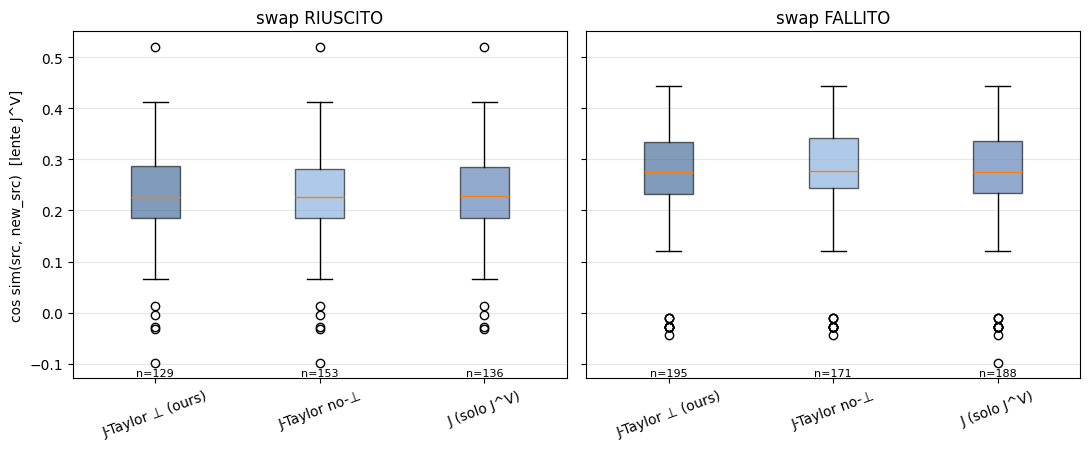

In [12]:
# 1.3 — Similarita' coseno src<->new_src (lente J^V) vs esito swap  [cella finale]
# Legge i risultati dalla cartella CACHE del notebook. Richiede lenti caricate (0.4-0.5).
J_METHODS = ["J-taylor", "J-taylor-raw", "J"]

def pair_similarity(src, new_src, layers=EDIT_LAYERS):
    sims = []
    for l in layers:
        v_s = concept_vec_cached(l, src, "V")
        v_t = concept_vec_cached(l, new_src, "V")
        cos = (v_s @ v_t) / (v_s.norm() * v_t.norm()).clamp_min(EPS)
        sims.append(cos.item())
    return float(np.mean(sims))

_pair_sim_cache = {}
def get_pair_sim(src, new_src):
    key = (src, new_src)
    if key not in _pair_sim_cache:
        _pair_sim_cache[key] = pair_similarity(src, new_src)
    return _pair_sim_cache[key]

sim_success = {m: [] for m in J_METHODS}
sim_fail    = {m: [] for m in J_METHODS}
for m in J_METHODS:
    d = load_json(f"part1_{m}")
    if d is None:
        print(f"[{m}] nessun risultato in {RESDIR}"); continue
    for r in d["records"]:
        sim = get_pair_sim(r["src"], r["new_src"])
        (sim_success if r["swap"] else sim_fail)[m].append(sim)

print(f"{'metodo':<20} | {'n succ':>6} | {'sim succ':>9} | {'n fail':>6} | {'sim fail':>9}")
for m in J_METHODS:
    ns, nf = len(sim_success[m]), len(sim_fail[m])
    ms = np.mean(sim_success[m]) if ns else float("nan")
    mf = np.mean(sim_fail[m]) if nf else float("nan")
    print(f"{MLABEL.get(m, m):<20} | {ns:>6} | {ms:>9.3f} | {nf:>6} | {mf:>9.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for j, (data, title) in enumerate([(sim_success, "swap RIUSCITO"), (sim_fail, "swap FALLITO")]):
    vals = [data[m] for m in J_METHODS]
    colors = [MCOLOR.get(m, "#888") for m in J_METHODS]
    bp = ax[j].boxplot(vals, labels=[MLABEL.get(m, m) for m in J_METHODS], patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(.6)
    ax[j].set_title(title)
    if j == 0: ax[j].set_ylabel("cos sim(src, new_src)  [lente J^V]")
    ax[j].tick_params(axis="x", rotation=20); ax[j].grid(axis="y", alpha=.3)
    ymin = ax[j].get_ylim()[0]
    for i, m in enumerate(J_METHODS):
        ax[j].text(i + 1, ymin, f"n={len(data[m])}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
savefig(fig, "fig_similarity_swap_success")
print("figura salvata in:", os.path.join(FIGDIR, "fig_similarity_swap_success.png"))
plt.show()

Leggo da: /raid/users/mmarchetti/VLM-TOMM/Prove/J/Analisi_Swap_VQA/risultati_swap_llava_vqa/results 

                                    n  removed  induced   swap
label                                                         
J-Taylor ⊥ (ours)                 324    0.537    0.488  0.398
J-Taylor no-⊥                     324    0.599    0.568  0.472
J (solo J^V)                      324    0.562    0.503  0.420
JV-pinv (Anthropic, J^V)          324    0.130    0.015  0.003
logit lens                        324    0.028    0.019  0.000
ProjectAway-logit (α=3.5)         324    0.071    0.006  0.000
PAI Eq.4 (paper, no target info)  324    0.083    0.006  0.000
PAI-targeted (src-conditioned)    324    0.080    0.003  0.000


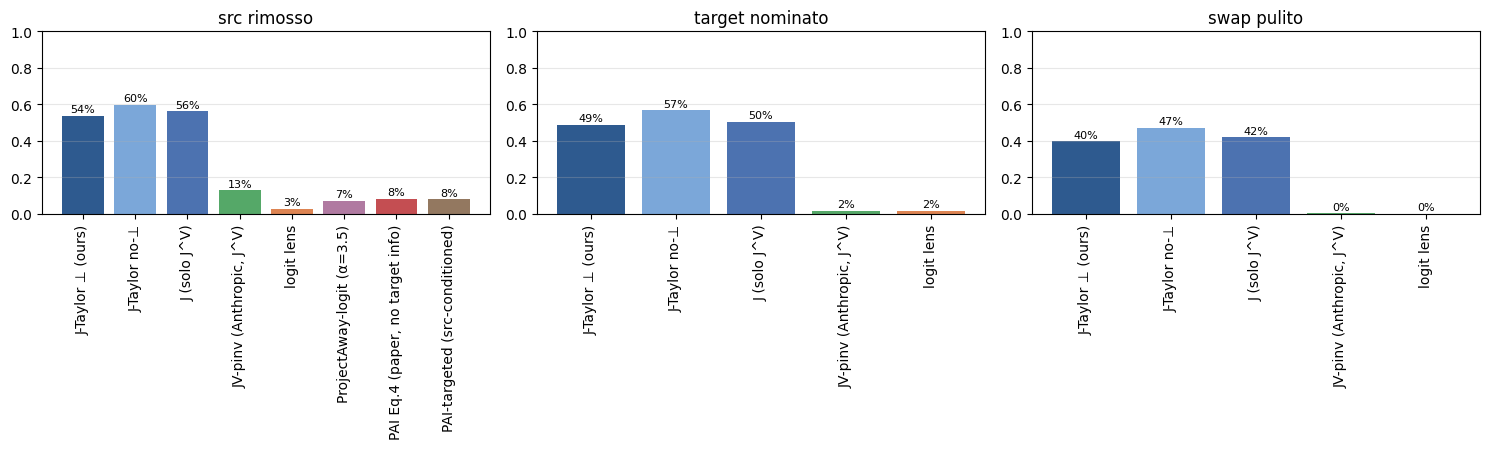


trial totali: 324 | completi da tutti i metodi: 324

trial #0  |  img=0  |  src='book'  ->  new_src='cup'
----------------------------------------------------------------------------------------------------
BASE                : In the image, you can see a computer desk with a laptop, a monitor, a keyboard, and a mouse. There are also several books on the desk, and a cell phone is
J-Taylor ⊥ (ours)   : In the image, you can see a computer desk with a laptop, a monitor, a keyboard, and a mouse. There is also a cell phone on the desk. Additionally, there are [removed]
J-Taylor no-⊥       : In the image, you can see a computer desk with a laptop, a monitor, a keyboard, and a mouse. There is also a cup placed on the desk. Additionally, there are [removed, induced, SWAP-OK]
J (solo J^V)        : In the image, you can see a computer desk with a laptop, a monitor, a keyboard, and a mouse. There is also a cell phone on the desk. Additionally, there are [removed]
JV-pinv (Anthropic, J^V): In t

In [13]:
# ============================================================================
# CELLA FINALE AUTONOMA — ricarica e mostra i risultati senza rilanciare nulla
# Non richiede modello, lenti o celle precedenti.
# ============================================================================
import os, json
import pandas as pd
import matplotlib.pyplot as plt

CACHE  = "./risultati_swap_llava_vqa"
RESDIR = os.path.join(CACHE, "results")
FIGDIR = os.path.join(CACHE, "figs")
os.makedirs(FIGDIR, exist_ok=True)
print("Leggo da:", os.path.abspath(RESDIR), "\n")

METHODS = ["J-taylor", "J-taylor-raw", "J", "JV-pinv", "logit",
           "project_away", "pai", "pai_targeted"]
SWAP_METHODS = {"J-taylor", "J-taylor-raw", "J", "JV-pinv", "logit"}
MLABEL = {"J-taylor": "J-Taylor \u22a5 (ours)", "J-taylor-raw": "J-Taylor no-\u22a5",
          "J": "J (solo J^V)", "JV-pinv": "JV-pinv (Anthropic, J^V)", "logit": "logit lens",
          "project_away": "ProjectAway-logit (\u03b1=3.5)",
          "pai": "PAI Eq.4 (paper, no target info)",
          "pai_targeted": "PAI-targeted (src-conditioned)"}
MCOLOR = {"J-taylor": "#2E5A8F", "J-taylor-raw": "#7BA7D9", "J": "#4C72B0",
          "JV-pinv": "#55A868", "logit": "#DD8452",
          "project_away": "#B07AA1", "pai": "#C44E52", "pai_targeted": "#937860"}

def _load(name):
    p = os.path.join(RESDIR, f"{name}.json")
    return json.load(open(p)) if os.path.exists(p) else None

# ---------------- 1) tabella reliability ----------------
RECS = {}
rows = []
for m in METHODS:
    d = _load(f"part1_{m}")
    recs = d.get("records", []) if d else []
    if not recs:
        print(f"[{m}] nessun risultato"); continue
    RECS[m] = recs
    n = len(recs)
    rows.append(dict(metodo=m, label=MLABEL[m], n=n,
                     removed=sum(r["removed"] for r in recs) / n,
                     induced=sum(r["new_mentioned"] for r in recs) / n,
                     swap=sum(r["swap"] for r in recs) / n))

if not rows:
    print("Nessun risultato in", RESDIR)
else:
    df = pd.DataFrame(rows).set_index("label")[["n", "removed", "induced", "swap"]]
    print(df.round(3).to_string())
    df.to_csv(os.path.join(RESDIR, "reliability_summary.csv"))

    # ---------------- 2) figura reliability ----------------
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    for j, (key, title) in enumerate([("removed", "src rimosso"),
                                      ("induced", "target nominato"),
                                      ("swap", "swap pulito")]):
        pr = rows if key == "removed" else [r for r in rows if r["metodo"] in SWAP_METHODS]
        ax[j].bar([r["label"] for r in pr], [r[key] for r in pr],
                  color=[MCOLOR[r["metodo"]] for r in pr])
        ax[j].set_ylim(0, 1); ax[j].set_title(title)
        ax[j].tick_params(axis="x", rotation=90); ax[j].grid(axis="y", alpha=.3)
        for i, r in enumerate(pr):
            ax[j].text(i, r[key] + 0.02, f"{r[key]:.0%}", ha="center", fontsize=8)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGDIR, "fig_reliability.png"), dpi=200, bbox_inches="tight")
    plt.show()

# ---------------- 3) esempi qualitativi ----------------
N_SHOW = 8
TS = _load("trials_shared")
if TS is None:
    print("\ntrials_shared.json non trovato: salto gli esempi")
elif RECS:
    TRIALS, BASE_CAPS = TS["trials"], TS["base_caps"]
    n_avail = min(len(v) for v in RECS.values())
    print(f"\ntrial totali: {len(TRIALS)} | completi da tutti i metodi: {n_avail}\n")
    for k in range(min(N_SHOW, n_avail)):
        tr = TRIALS[k]
        print("=" * 100)
        print(f"trial #{k}  |  img={tr['img']}  |  src='{tr['src']}'  ->  new_src='{tr['new_src']}'")
        print("-" * 100)
        print(f"{'BASE':<20}: {BASE_CAPS[tr['img']]}")
        for m in METHODS:
            if m not in RECS or k >= len(RECS[m]): continue
            r = RECS[m][k]
            flag = [f for f, on in (("removed", r["removed"]),
                                    ("induced", r["new_mentioned"]),
                                    ("SWAP-OK", r["swap"])) if on]
            print(f"{MLABEL[m]:<20}: {r['edited_desc']}"
                  + (f" [{', '.join(flag)}]" if flag else ""))
        print()